# 03. Experimentos

BGE-M3 y Salamandra. Comparamos recuperación densa, híbrida y densa con reranker.

Cada respuesta se guarda al terminar. Las tablas muestran puntaje, tiempos y errores. Los resultados y decisiones se escriben después de revisar la ejecución.


## Entorno

En Colab, subir `ai-week-experimentos.zip` a `Mi unidad/AIWEEK`, sin descomprimir, y abrir este notebook con GPU L4 o A100. El ZIP anterior y su carpeta de resultados sirven para encontrar el índice ya construido.

En local, abrir este notebook desde el proyecto con el entorno de experimentación.

Si la instalación pide reiniciar, reiniciar la sesión y ejecutar desde el comienzo. La preparación descarga modelos la primera vez. Salamandra convertido se guarda en Drive para las siguientes sesiones.


In [1]:
from pathlib import Path
import hashlib
import importlib.metadata
import json
import os
import platform
import shutil
import subprocess
import sys
import zipfile

MODO = "auto"
CARPETA_DRIVE = "/content/drive/MyDrive/AIWEEK"

os.environ["USE_TF"] = "0"
os.environ["USE_TORCH"] = "1"
os.environ["USE_FLAX"] = "0"
os.environ["TRANSFORMERS_NO_TF"] = "1"
os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"

try:
    import google.colab
    detectado_colab = True
except ImportError:
    detectado_colab = False
if MODO not in {"auto", "local", "colab"}:
    raise ValueError("MODO debe ser auto, local o colab")
EN_COLAB = detectado_colab if MODO == "auto" else MODO == "colab"

def hash_archivo(ruta):
    h = hashlib.sha256()
    with Path(ruta).open("rb") as archivo:
        for bloque in iter(lambda: archivo.read(8 * 1024 * 1024), b""):
            h.update(bloque)
    return h.hexdigest()

if EN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")
    DRIVE = Path(CARPETA_DRIVE)
    paquete = DRIVE / "ai-week-experimentos.zip"
    if not paquete.is_file():
        raise FileNotFoundError(f"Subir ai-week-experimentos.zip a {DRIVE}")
    identificador = hash_archivo(paquete)
    RAIZ = Path("/content/aiweek") / ("experimentos-" + identificador[:12])
    if not (RAIZ / ".paquete_verificado").is_file():
        RAIZ.mkdir(parents=True, exist_ok=True)
        with zipfile.ZipFile(paquete) as z:
            for nombre in z.namelist():
                if not (RAIZ / nombre).resolve().is_relative_to(RAIZ.resolve()):
                    raise ValueError("Ruta inválida dentro del ZIP")
            z.extractall(RAIZ)
        inventario = json.loads((RAIZ / "paquete.json").read_text(encoding="utf-8"))
        for nombre, esperado in inventario["sha256_archivos"].items():
            if hash_archivo(RAIZ / nombre) != esperado:
                raise ValueError(f"Archivo incompleto: {nombre}")
        (RAIZ / ".paquete_verificado").write_text(identificador)
    dependencias = RAIZ / "requirements-colab.txt"
    firma = hash_archivo(dependencias) + platform.python_version()
    marca = Path("/content/aiweek_experimentos_dependencias.txt")
    if not marca.exists() or marca.read_text() != firma:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-r", str(dependencias)], check=True)
        marca.write_text(firma)
    for nombre in ("numpy", "pandas", "transformers", "tokenizers"):
        if nombre in sys.modules and getattr(sys.modules[nombre], "__version__", None) != importlib.metadata.version(nombre):
            raise RuntimeError("Reiniciar la sesión de Colab y ejecutar desde el principio")
    RESULTADOS = DRIVE / "experimentos"
    FUENTES_INDICES = [DRIVE / "resultados", RAIZ / "data/index"]
    CACHE_MODELOS = DRIVE / "modelos_cache"
    os.environ["HF_HOME"] = str(RAIZ / "data/cache_huggingface")
else:
    RAIZ = next((p for p in [Path.cwd(), *Path.cwd().parents] if (p / "configs/experimentos.json").is_file()), None)
    if RAIZ is None:
        raise FileNotFoundError("Abrir el notebook desde el proyecto o notebooks")
    RESULTADOS = RAIZ / "data/experimentos_sistema"
    FUENTES_INDICES = [RAIZ / "data/index", RAIZ / "data/experimentos_oficiales"]
    CACHE_MODELOS = None

for nombre, modulo in list(sys.modules.items()):
    if nombre == "scripts" or nombre.startswith("scripts."):
        archivo = getattr(modulo, "__file__", None)
        rutas = [archivo] if archivo else list(getattr(modulo, "__path__", []))
        if any(not Path(r).resolve().is_relative_to(RAIZ.resolve()) for r in rutas):
            raise RuntimeError("Hay código de otro paquete cargado. Reiniciar la sesión y ejecutar desde el inicio")

os.chdir(RAIZ)
if str(RAIZ) not in sys.path:
    sys.path.insert(0, str(RAIZ))
RESULTADOS.mkdir(parents=True, exist_ok=True)
print("Entorno:", "Colab" if EN_COLAB else "local")
print("Resultados:", RESULTADOS)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Entorno: Colab
Resultados: /content/drive/MyDrive/AIWEEK/experimentos


## Configuración

| Variante | Recuperación | Artículos finales |
|---|---|---:|
| densa | BGE + FAISS | 5 |
| hibrida | BGE + BM25 | 5 |
| densa_reranker | BGE recupera 20 y un reranker abierto los ordena | 5 |

Las tres usan el mismo corpus, Salamandra, instrucciones y temperatura. El reranker es `BAAI/bge-reranker-v2-m3`, con licencia Apache 2.0 y revisión fijada en la configuración.

`reanudar = "auto"` continúa la última ejecución. Para una ejecución nueva, usar `reanudar = ""`. Al retomar, mantener variantes, configuración y tipo de GPU. Los cambios incompatibles se informan antes de mezclar respuestas.

`permitir_construir = False` exige encontrar un índice compatible. Solo cambiarlo a `True` si se necesita construirlo desde el corpus incluido.


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import torch
from scripts.auxiliares.entorno import hardware
from scripts.auxiliares.experimentos import (
    preparar_recuperaciones, ejecutar_experimentos, evaluar_experimentos, evaluar_ragas,
)

variantes = ["densa", "hibrida", "densa_reranker"]
reanudar = "auto"
permitir_construir = False

if not torch.cuda.is_available():
    raise RuntimeError("Seleccionar una GPU en Colab o usar un entorno local con CUDA")
print(hardware())
config = json.loads((RAIZ / "configs/experimentos.json").read_text(encoding="utf-8"))
display(pd.DataFrame([v for v in config["variantes"] if v["nombre"] in variantes]))


NVIDIA A100-SXM4-40GB, 40960 MiB, 8.0


,nombre,hibrido,candidatos,max_unidades,reranker
0,densa,False,5,5,False
1,hibrida,True,5,5,False
2,densa_reranker,False,20,5,True


## Recuperación

Se buscan índices BGE guardados en las carpetas anteriores. Se comprueban modelo, corpus, segmentación y archivos antes de reutilizarlos. Añadir un experimento no obliga a volver a crear los vectores.

Las respuestas esperadas se usan únicamente para evaluar. La recuperación y Salamandra reciben la pregunta y sus opciones, cuando existen.


In [3]:
nombre_ejecucion = ""
carpeta_recuperacion = None
puntero = RESULTADOS / "ultima_ejecucion.json"
if reanudar == "auto" and puntero.is_file():
    anterior = json.loads(puntero.read_text(encoding="utf-8"))
    nombre_ejecucion = Path(anterior["carpeta"]).name
    carpeta_recuperacion = RESULTADOS / anterior["recuperacion"]
elif reanudar not in {"", "auto"}:
    if Path(reanudar).name != reanudar:
        raise ValueError("Usar solo el nombre de la ejecución")
    nombre_ejecucion = reanudar
    anterior = json.loads((RESULTADOS / "ejecuciones" / reanudar / "configuracion.json").read_text(encoding="utf-8"))
    carpeta_recuperacion = RESULTADOS / anterior["recuperacion"]

if carpeta_recuperacion is None:
    carpeta_recuperacion = preparar_recuperaciones(
        RAIZ, RESULTADOS, fuentes_indices=FUENTES_INDICES,
        variantes=variantes, device="cuda", batch_size=4,
        permitir_construir=permitir_construir,
    )
print("Recuperación:", carpeta_recuperacion)
print("Ejecución:", nombre_ejecucion or "nueva")


Recuperación reutilizada: 20260927T232943218185Z
Recuperación: /content/drive/MyDrive/AIWEEK/experimentos/recuperaciones/20260927T232943218185Z
Ejecución: nueva


## Ejecución

Se carga únicamente Salamandra. La primera conversión requiere 45 GiB libres. Después se reutiliza el modelo convertido y verificado.

Cada pregunta terminada queda guardada. Una interrupción técnica se registra como error y no se convierte en abstención jurídica. La evaluación se ejecuta al completar las 50 preguntas de cada variante.


In [4]:
carpeta = ejecutar_experimentos(
    RAIZ, carpeta_recuperacion, RESULTADOS,
    variantes=variantes, reanudar=nombre_ejecucion,
    cache_modelos=CACHE_MODELOS,
)
print("Ejecución guardada:", carpeta)


Verificado: config.json
Verificado: generation_config.json
model-00001-of-00004.safetensors: 46.3%
model-00001-of-00004.safetensors: 94.2%
Verificado: model-00001-of-00004.safetensors
model-00002-of-00004.safetensors: 46.7%
model-00002-of-00004.safetensors: 92.1%
Verificado: model-00002-of-00004.safetensors
model-00003-of-00004.safetensors: 86.0%
Verificado: model-00003-of-00004.safetensors
Verificado: model-00004-of-00004.safetensors
Verificado: model.safetensors.index.json
Verificado: special_tokens_map.json
Verificado: tokenizer.json
Verificado: tokenizer.model
Verificado: tokenizer_config.json
Guardando Salamandra para la siguiente sesión
densa: 1/50 respondidas
densa: 2/50 respondidas
densa: 3/50 respondidas
densa: 4/50 respondidas
densa: 5/50 respondidas
densa: 6/50 respondidas
densa: 7/50 respondidas
densa: 8/50 respondidas
densa: 9/50 respondidas
densa: 10/50 respondidas
densa: 11/50 respondidas
densa: 12/50 respondidas
densa: 13/50 respondidas
densa: 14/50 respondidas
densa: 1

## Resultados

El evaluador sin llave mide 50 puntos. La corrección de texto libre queda pendiente hasta usar el juez oficial.

El recall de normas no comprueba que el artículo responda la pregunta. Las comprobaciones de citas señalan presencia y coincidencias, no validez jurídica. La latencia suma recuperación precalculada y generación.


,variante,estado,respuestas,preguntas,puntos_offline_50,total_50,total_80,cerradas_20,citas_20,abstencion_10,...,recuperacion_s,reintentos,abstenciones,abstenciones_programaticas,contextos_omitidos,respuestas_con_omisiones,articulos_sin_respaldo,respuestas_revision_articulos,errores_esquema,abstenciones_cerradas_null
0,densa,completo,50,50,11.04,11.04,NaN,4.00,2.04,5.00,...,0.183137,0,38,12,4,3,0,46,11,11
1,hibrida,completo,50,50,10.68,10.68,NaN,5.33,0.82,4.53,...,1.458462,0,32,10,11,10,0,48,6,6
2,densa_reranker,completo,50,50,14.35,14.35,NaN,6.67,2.45,5.23,...,0.724902,0,35,15,7,7,2,47,7,7


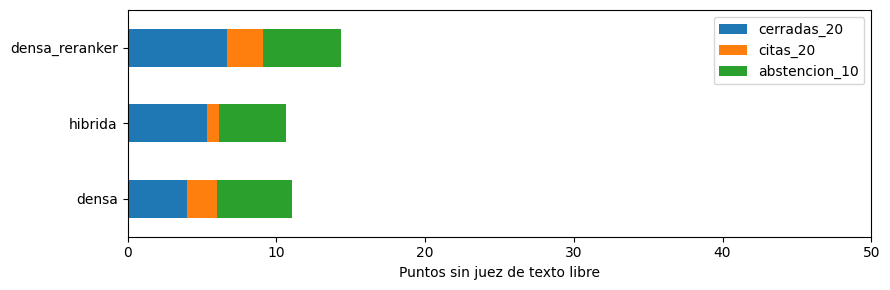

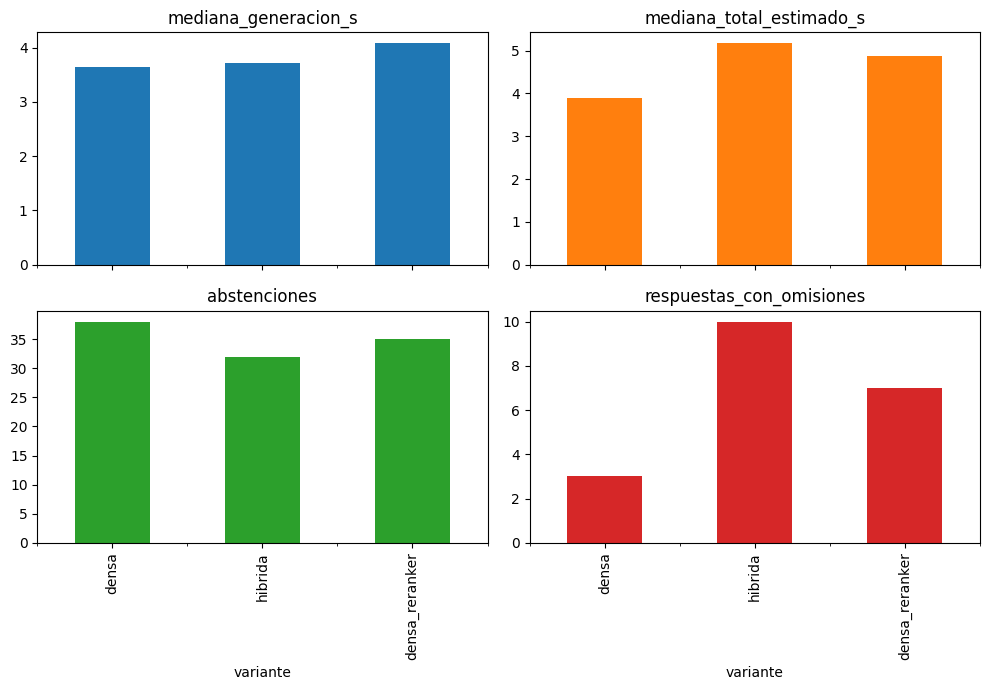

In [5]:
evaluar_experimentos(RAIZ, carpeta, variantes=variantes)
tabla = pd.read_csv(carpeta / "resumen.csv")
detalle = pd.read_csv(carpeta / "por_pregunta.csv")
display(tabla)

puntos = [c for c in ["cerradas_20", "citas_20", "abstencion_10"] if c in tabla]
if puntos:
    tabla.set_index("variante")[puntos].plot.barh(stacked=True, xlim=(0, 50), figsize=(9, 3))
    plt.xlabel("Puntos sin juez de texto libre")
    plt.ylabel("")
    plt.tight_layout()
    plt.show()

columnas = [c for c in ["mediana_generacion_s", "mediana_total_estimado_s", "abstenciones", "respuestas_con_omisiones"] if c in tabla]
if columnas:
    tabla.set_index("variante")[columnas].plot.bar(subplots=True, layout=(2, 2), figsize=(10, 7), legend=False)
    plt.tight_layout()
    plt.show()


## Errores y diferencias

Revisar dónde cambia el resultado entre variantes. Separar fuente ausente, recuperación insuficiente, contexto omitido, error de generación y cita sin respaldo. Una mejora agregada puede ocultar una caída en alguna de las áreas.


In [6]:
columnas = [c for c in ["variante", "id", "area", "formato", "acierto_cerrada", "abstencion", "motivo", "recall_normas_5", "citas_sin_respaldo", "articulos_sin_respaldo", "revision_articulos", "contextos_omitidos", "segundos_generacion", "intentos", "segundos_reintentos"] if c in detalle]
display(detalle[columnas])
for nombre in ["por_area.csv", "por_formato.csv"]:
    archivo = carpeta / nombre
    if archivo.is_file():
        print(nombre)
        display(pd.read_csv(archivo))

if {"id", "variante", "acierto_cerrada"}.issubset(detalle.columns):
    comparacion = detalle.pivot(index="id", columns="variante", values="acierto_cerrada")
    display(comparacion[comparacion.nunique(axis=1, dropna=True) > 1])


,variante,id,area,formato,acierto_cerrada,abstencion,motivo,recall_normas_5,articulos_sin_respaldo,revision_articulos,contextos_omitidos,segundos_generacion,segundos_reintentos
0,densa,51,Derecho constitucional,multiple_choice,False,True,NaN,0.5,0,True,0,3.192044,0.0
1,densa,58,"Derecho de los mercados [competencia, consumid...",multiple_choice,False,True,NaN,0.0,0,True,0,2.963228,0.0
2,densa,60,Derecho procesal,multiple_choice,True,False,NaN,0.0,0,True,0,2.995367,0.0
3,densa,128,Derecho comercial y sociedades,multiple_choice,False,True,NaN,1.0,0,True,0,2.210663,0.0
4,densa,290,Derecho administrativo,multiple_choice,False,False,NaN,1.0,0,False,0,3.565303,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
145,densa_reranker,1005,Derecho constitucional,semi_open,NaN,False,NaN,1.0,1,True,0,3.051039,0.0
146,densa_reranker,1015,Derecho penal,semi_open,NaN,True,formato_invalido,1.0,0,True,0,10.013555,0.0
147,densa_reranker,1065,Derecho penal,semi_open,NaN,True,NaN,1.0,0,True,0,3.137297,0.0
148,densa_reranker,1073,Derecho laboral,semi_open,NaN,True,formato_invalido,0.0,0,True,0,9.212011,0.0


por_area.csv


,variante,area,preguntas,acierto_cerradas,recall_normas_5,recall_citas,precision_citas,abstenciones
0,densa,Derecho administrativo,7,0.0,0.200000,0.20,0.500000,4
1,densa,Derecho civil,4,0.0,0.000000,0.00,NaN,4
2,densa,Derecho comercial y sociedades,5,0.0,0.500000,0.25,1.000000,3
3,densa,Derecho constitucional,6,0.5,0.500000,0.20,0.333333,3
4,densa,Derecho de familia,5,0.5,0.000000,0.00,NaN,4
5,densa,"Derecho de los mercados [competencia, consumid...",5,0.0,0.750000,0.25,0.250000,4
6,densa,Derecho laboral,5,0.0,0.266667,0.00,NaN,5
7,densa,Derecho penal,4,0.0,1.000000,0.25,1.000000,3
8,densa,Derecho procesal,5,0.5,0.600000,0.00,NaN,4
9,densa,Derecho tributario,4,0.0,0.000000,0.00,NaN,4


por_formato.csv


,variante,formato,preguntas,acierto_cerradas,recall_normas_5,recall_citas,precision_citas,abstenciones
0,densa,multiple_choice,15,0.200000,0.423077,0.153846,1.000000,11
1,densa,open_ended,5,NaN,0.333333,0.250000,0.500000,2
2,densa,semi_open,30,NaN,0.416667,0.083333,0.312500,25
3,densa_reranker,multiple_choice,15,0.333333,0.423077,0.192308,0.833333,7
4,densa_reranker,open_ended,5,NaN,0.333333,0.250000,0.500000,3
5,densa_reranker,semi_open,30,NaN,0.416667,0.083333,0.500000,25
6,hibrida,multiple_choice,15,0.266667,0.423077,0.000000,NaN,6
7,hibrida,open_ended,5,NaN,0.250000,0.000000,0.000000,3
8,hibrida,semi_open,30,NaN,0.416667,0.083333,0.150000,23


variante,densa,densa_reranker,hibrida
id,,,
51,False,False,True
60,True,True,False
358,False,True,False
600,False,True,True


## Revisar una pregunta

Comparar la respuesta de cada variante con sus artículos utilizados. La referencia oficial aparece solo en esta revisión, después de generar.


In [7]:
from IPython.display import display
from scripts.auxiliares.oficial import cargar_muestra

preguntas, _ = cargar_muestra(RAIZ)
id_revisar = preguntas[0]["id"]
caso = next(p for p in preguntas if p["id"] == id_revisar)
print(caso["pregunta"])
for variante in variantes:
    ruta = carpeta / variante / "respuestas" / f"{id_revisar}.json"
    registro = json.loads(ruta.read_text(encoding="utf-8"))
    respuesta = registro["respuesta"]
    print("\nVariante:", variante)
    display({k: v for k, v in respuesta.items() if k != "pasajes_recuperados"})
    pasajes = pd.DataFrame(respuesta["pasajes_recuperados"])
    if not pasajes.empty:
        display(pasajes[[c for c in ["doc_id", "articulo", "tipo_evidencia", "texto"] if c in pasajes]])
    if registro["registro"].get("omitidos"):
        display(pd.DataFrame(registro["registro"]["omitidos"]))
print("\nReferencia oficial para revisión:")
display({k: caso[k] for k in ["respuesta_correcta", "respuesta_esperada", "legal_basis"] if k in caso})


¿En cuál de los siguientes casos procede la acción judicial de grupo? 

Variante: densa


{'id': 51,
 'formato': 'multiple_choice',
 'respuesta_correcta': None,
 'justificacion': '',
 'descarte_opciones': {},
 'abstencion': True}

,doc_id,articulo,tipo_evidencia,texto
0,co_ley_472_1998,NaN,cabecera_fuente,LEY 472 DE 1998
1,co_ley_472_1998,2,unidad,ARTÍCULO 2º.- Acciones Populares. Son los medi...
2,co_ley_472_1998,NaN,cabecera_fuente,LEY 472 DE 1998
3,co_ley_472_1998,3,unidad,ARTÍCULO 3º.- Acción de Grupo. Son aquellas ac...
4,co_ley_472_1998,NaN,cabecera_fuente,LEY 472 DE 1998
5,co_ley_472_1998,46,unidad,ARTÍCULO 46.- Procedencia de las Acciones de G...
6,co_ley_1437_2011,NaN,cabecera_fuente,LEY 1437 DE 2011
7,co_ley_1437_2011,144,unidad,ARTÍCULO 144. Protección de los derechos e int...
8,co_ley_472_1998,NaN,cabecera_fuente,LEY 472 DE 1998
9,co_ley_472_1998,21,unidad,ARTÍCULO 21.- Notificación del Auto Admisorio ...



Variante: hibrida


{'id': 51,
 'formato': 'multiple_choice',
 'respuesta_correcta': 'C',
 'justificacion': 'Cuando un conjunto de personas resulta afectado por un mismo hecho que les causa perjuicios individuales derivados de una causa común.',
 'descarte_opciones': {'A': 'Cuando un grupo de personas busca proteger derechos fundamentales individuales de aplicación inmediata.',
  'B': 'Cuando un grupo de ciudadanos busca defender el interés colectivo ambiental o del espacio público.',
  'D': 'Cuando se pretende declarar la inconstitucionalidad de una norma con fuerza de ley.'},
 'abstencion': False}

...


Variante: densa_reranker


{'id': 51,
 'formato': 'multiple_choice',
 'respuesta_correcta': None,
 'justificacion': '',
 'descarte_opciones': {},
 'abstencion': True}

,doc_id,articulo,tipo_evidencia,texto
0,co_ley_472_1998,NaN,cabecera_fuente,LEY 472 DE 1998
1,co_ley_472_1998,46,unidad,ARTÍCULO 46.- Procedencia de las Acciones de G...
2,co_ley_472_1998,NaN,cabecera_fuente,LEY 472 DE 1998
3,co_ley_472_1998,58,unidad,ARTÍCULO 58.- Clases de Medidas. Para las acci...
4,co_ley_472_1998,NaN,cabecera_fuente,LEY 472 DE 1998
5,co_ley_472_1998,48,unidad,ARTÍCULO 48.- Titulares de las Acciones. Podrá...
6,co_ley_472_1998,NaN,cabecera_fuente,LEY 472 DE 1998
7,co_ley_472_1998,3,unidad,ARTÍCULO 3º.- Acción de Grupo. Son aquellas ac...
8,co_ley_472_1998,NaN,cabecera_fuente,LEY 472 DE 1998
9,co_ley_472_1998,55,unidad,ARTÍCULO 55.- Integración al Grupo. Cuando la ...



Referencia oficial para revisión:


{'respuesta_correcta': 'C',
 'legal_basis': 'Constitución Política, artículo 88; Ley 472 de 1998, artículos 3 y 46.'}

## Juez de texto libre

Opcional. Evaluar primero sin llave y usar el juez para los finalistas. En Colab, la llave oficial se guarda en Secretos como `OPENROUTER_API_KEY`. Solo se entrega al evaluador.

Esta celda instala sus dependencias al final. Una evaluación ya guardada se reutiliza. Para repetir una llamada pagada, cambiar también `repetir_juez`.


In [8]:
usar_juez = False
finalistas = ["densa_reranker"]
repetir_juez = False

if usar_juez:
    subprocess.run([sys.executable, "-m", "pip", "install", "-r",
                    str(RAIZ / "data/oficial/scripts/requirements-evaluador.txt")], check=True)
    clave_anterior = os.environ.get("OPENROUTER_API_KEY")
    try:
        if EN_COLAB:
            from google.colab import userdata
            os.environ["OPENROUTER_API_KEY"] = userdata.get("OPENROUTER_API_KEY")
        if not os.environ.get("OPENROUTER_API_KEY"):
            raise RuntimeError("Falta la llave oficial del evaluador")
        for variante in finalistas:
            reporte = evaluar_ragas(RAIZ, carpeta, variante, repetir=repetir_juez)
            display(pd.DataFrame([{"variante": variante, **reporte["correccion_ragas"]}]))
    finally:
        if clave_anterior is None:
            os.environ.pop("OPENROUTER_API_KEY", None)
        else:
            os.environ["OPENROUTER_API_KEY"] = clave_anterior


## Resultados

Se ejecutaron las tres variantes sobre las 50 preguntas de muestra en A100. El juez de texto libre no se ejecutó, así que solo tenemos 50 de los 80 puntos automáticos.

| Variante | Puntos / 50 | Cerradas / 20 | Citas / 20 | Abstención / 10 | Abstenciones |
|---|---:|---:|---:|---:|---:|
| Densa | 11,04 | 4,00 | 2,04 | 5,00 | 38/50 |
| Híbrida | 10,68 | 5,33 | 0,82 | 4,53 | 32/50 |
| Densa con reranker | 14,35 | 6,67 | 2,45 | 5,23 | 35/50 |

